In [39]:
import matplotlib.pyplot as plt
import pandas as pd
from textwrap import fill

plt.style.use("mystyle.mplstyle")

def add_percentage_labels(ax, counts, total):
    label_offset = ax.get_xlim()[1] * 0.015
    for y, value in enumerate(counts.values):
        percentage = value / total * 100
        ax.text(
            value + label_offset,
            y,
            f"{percentage:.1f}%",
            va="center",
            color="0.25",
        )

figures_path = "../../literature-review-paper/src/figures/"

In [40]:
columns = [
    "paper_id",
    "publication_year",
    "publication_type",
    "venue_type",
    "research_type",
    "methodological_approach",
    "data_source",
    "assessment_orientation",
    "Environmental impacts",
    "Lifecycle stages",
    "System locus",
    "Management and intervention levers"
]

df = pd.read_csv(
    "../artifacts/merge.csv",
    usecols=columns
)
df.head()

,paper_id,publication_year,publication_type,venue_type,research_type,methodological_approach,data_source,assessment_orientation,Environmental impacts,Lifecycle stages,System locus,Management and intervention levers
0,1,2025,Conference Paper,Other Venues,Philosophical Paper,literature analysis,secondary,ex post,Carbon emissions and footprint,Operational use and control,Operational governance and user practices,Incentives and strategic framing
1,2,2011,Journal Paper,Parallel and Distributed Venues,Validation Research,modeling;simulations,secondary,ex ante,Carbon emissions and footprint,Operational use and control,"Facility, thermal, and energy infrastructure;S...",Runtime control and workload optimization
2,3,2024,Conference Paper,HPC Venues,Validation Research,data analysis;modeling;simulations,primary,ex post;ex ante,"Material, waste, and resource burdens",Upstream planning and procurement;Operational ...,"Facility, thermal, and energy infrastructure;C...","Measurement, accounting, and visibility;Runtim..."
3,4,2024,Conference Paper,HPC Venues,Experience Paper,data analysis;modeling;experiments on real sys...,primary,ex post,Carbon emissions and footprint,Operational use and control,Operational governance and user practices,Runtime control and workload optimization;Ince...
4,5,2019,Conference Paper,Parallel and Distributed Venues,Experience Paper,data analysis;modeling,primary;secondary,ex ante,Water use and hydrological impacts,Upstream planning and procurement;Operational ...,"Facility, thermal, and energy infrastructure",Infrastructure and cooling design


In [41]:
for col in columns[5:]:
    df[col] = df[col].str.split(";").apply(lambda vals: [v.strip() for v in vals])
df.head()

,paper_id,publication_year,publication_type,venue_type,research_type,methodological_approach,data_source,assessment_orientation,Environmental impacts,Lifecycle stages,System locus,Management and intervention levers
0,1,2025,Conference Paper,Other Venues,Philosophical Paper,[literature analysis],[secondary],[ex post],[Carbon emissions and footprint],[Operational use and control],[Operational governance and user practices],[Incentives and strategic framing]
1,2,2011,Journal Paper,Parallel and Distributed Venues,Validation Research,"[modeling, simulations]",[secondary],[ex ante],[Carbon emissions and footprint],[Operational use and control],"[Facility, thermal, and energy infrastructure,...",[Runtime control and workload optimization]
2,3,2024,Conference Paper,HPC Venues,Validation Research,"[data analysis, modeling, simulations]",[primary],"[ex post, ex ante]","[Material, waste, and resource burdens]","[Upstream planning and procurement, Operationa...","[Facility, thermal, and energy infrastructure,...","[Measurement, accounting, and visibility, Runt..."
3,4,2024,Conference Paper,HPC Venues,Experience Paper,"[data analysis, modeling, experiments on real ...",[primary],[ex post],[Carbon emissions and footprint],[Operational use and control],[Operational governance and user practices],"[Runtime control and workload optimization, In..."
4,5,2019,Conference Paper,Parallel and Distributed Venues,Experience Paper,"[data analysis, modeling]","[primary, secondary]",[ex ante],[Water use and hydrological impacts],"[Upstream planning and procurement, Operationa...","[Facility, thermal, and energy infrastructure]",[Infrastructure and cooling design]


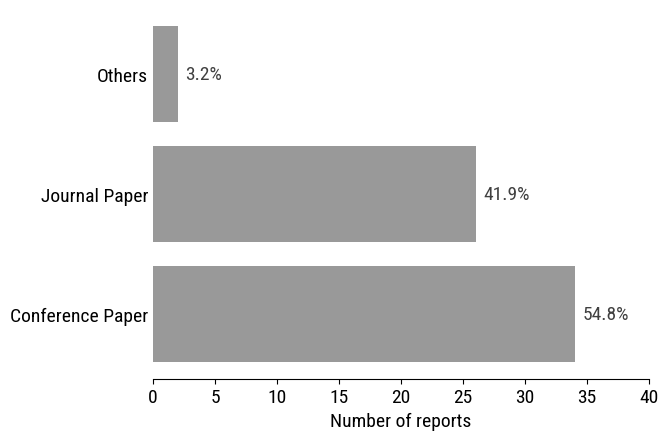

In [42]:
def publication_type_plot(df):
    publication_type_counts = df["publication_type"].value_counts()

    fig, ax = plt.subplots()

    plt.barh(
        publication_type_counts.index,
        publication_type_counts.values,
        color="0.6",
    )
    
    ax.set_ylabel("")
    ax.set_xlabel("Number of reports")

    ax.set_xlim(0, 40)
    
    ax.tick_params(axis="y",length=0)
    
    ax.spines[["right", "left", "top"]].set_visible(False)

    add_percentage_labels(ax, publication_type_counts, len(df))

    # plt.savefig(figures_path + "publication_type.pdf", bbox_inches="tight")
    plt.show()

publication_type_plot(df)

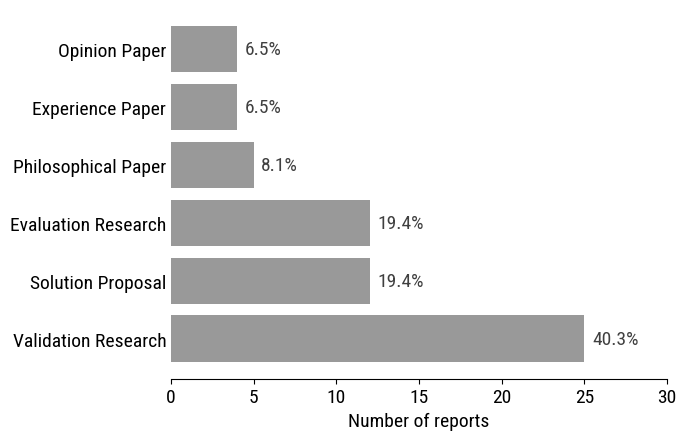

In [43]:
def research_type_plot(df):
    research_type_counts = df["research_type"].value_counts()

    fig, ax = plt.subplots()

    plt.barh(
        research_type_counts.index,
        research_type_counts.values,
        color="0.6",
    )
    
    plt.ylabel("")
    plt.xlabel("Number of reports")

    plt.xlim(0, 30)

    ax.spines[["right", "left", "top"]].set_visible(False)
    
    plt.tick_params(axis="y",length=0)

    add_percentage_labels(ax, research_type_counts, len(df))

    # plt.savefig(figures_path + "research_type.pdf", bbox_inches="tight")
    plt.show()

research_type_plot(df)

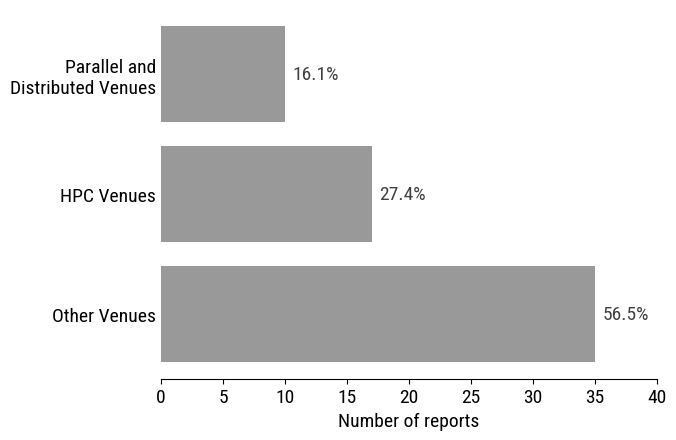

In [44]:
def venue_type_plot(df):
    venue_type_counts = df["venue_type"].value_counts()

    fig, ax = plt.subplots()

    wrapped_index = [fill(s, width=20) for s in venue_type_counts.index]

    ax.barh(
        wrapped_index,
        venue_type_counts.values,
        color="0.6",
    )
    
    ax.set_ylabel("")
    ax.set_xlabel("Number of reports")

    ax.set_xlim(0, 40)

    ax.spines[["right", "left", "top"]].set_visible(False)
    
    ax.tick_params(axis="y",length=0)

    add_percentage_labels(ax, venue_type_counts, len(df))

    # plt.savefig(figures_path + "venue_type.pdf", bbox_inches="tight")
    plt.show()

venue_type_plot(df)

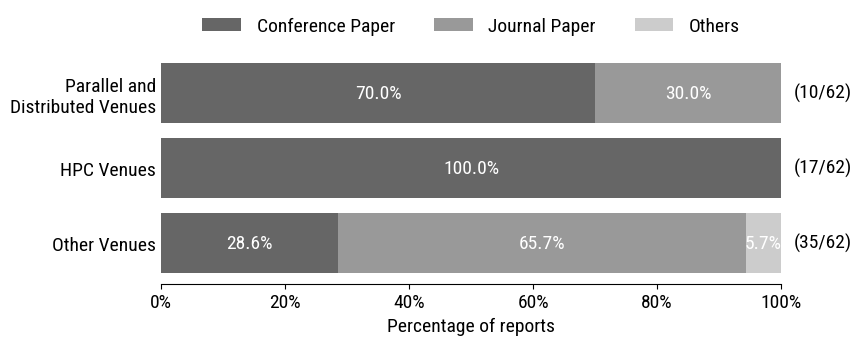

In [45]:
def venue_type_by_publication_plot(df):
    ct = pd.crosstab(df["venue_type"], df["publication_type"])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct = ct_pct.loc[df["venue_type"].value_counts().index]
    totals = ct.sum(axis=1).loc[ct_pct.index]

    grays = ["0.4", "0.6", "0.8"]
    left = [0.0] * len(ct_pct)

    fig, ax = plt.subplots(figsize=(8, 3))

    for i, pub_type in enumerate(ct_pct.columns):
        values = ct_pct[pub_type]
        wrapped_index = [fill(s, width=20) for s in ct_pct.index]
        ax.barh(wrapped_index, values, left=left, color=grays[i], label=pub_type)
        for j, (v, l) in enumerate(zip(values, left)):
            if v >= 5:
                ax.text(
                    l + v / 2, j,
                    f"{v:.1f}%",
                    ha="center", va="center",
                    color="white",
                )
        left = [l + v for l, v in zip(left, values)]

    n_totals = sum(totals)
    for j, (venue, n) in enumerate(totals.items()):
        ax.text(102, j, f"({n}/{n_totals})", va="center")

    ax.set_xlim(0, 100)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}%"))
    ax.set_xlabel("Percentage of reports")
    ax.set_ylabel("")
    ax.tick_params(axis="y", length=0)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncols=3)

    ax.spines[["right", "left", "top"]].set_visible(False)

    plt.savefig(figures_path + "venue_type_by_publication.pdf", bbox_inches="tight")
    plt.show()

venue_type_by_publication_plot(df)

venue_type        Other Venues  HPC Venues  Parallel and Distributed Venues
publication_year                                                           
2010                         3           0                                0
2011                         1           0                                1
2012                         0           0                                0
2013                         1           1                                1
2014                         1           0                                1
2015                         1           0                                0
2016                         0           0                                0
2017                         0           0                                0
2018                         1           0                                0
2019                         2           0                                2
2020                         1           0                                0
2021        

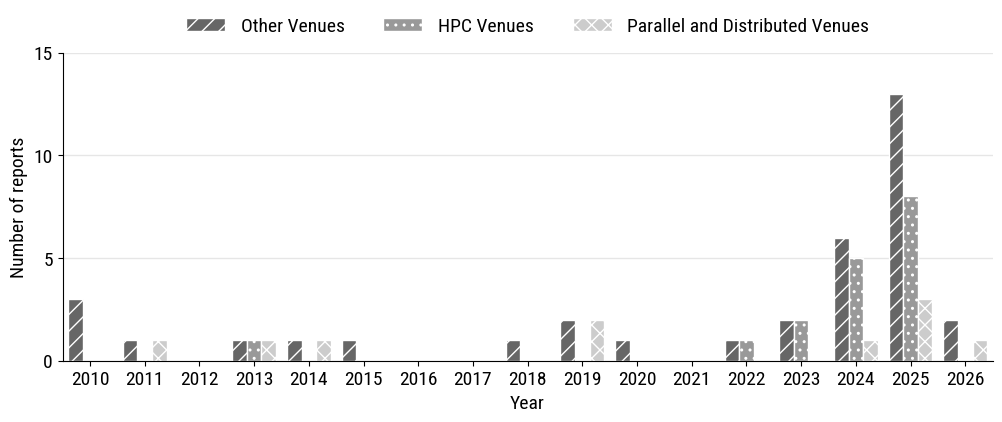

In [46]:
def venue_type_by_year_plot(df):
    venue_order = df["venue_type"].value_counts().index.tolist()
    years = list(range(2010, 2027))

    ct = pd.crosstab(df["publication_year"], df["venue_type"]).reindex(
        index=years, columns=venue_order, fill_value=0
    )

    print(ct)
    print()
    print("Totals by year:")
    print(ct.sum(axis=1))
    print()
    print("Totals by venue:")
    print(ct.sum(axis=0))

    grays = ["0.4", "0.6", "0.8"]
    hatches = ["//", "..", "xx"]
    width = 0.8 / len(venue_order)
    offsets = [(i - (len(venue_order) - 1) / 2) * width for i in range(len(venue_order))]

    fig, ax = plt.subplots(figsize=(12, 4))

    for venue, color, hatch, offset in zip(venue_order, grays, hatches, offsets):
        ax.bar(
            ct.index + offset,
            ct[venue].values,
            width=width,
            color=color,
            hatch=hatch,
            edgecolor="white",
            label=venue,
        )

    ax.set_xlim(years[0] - 0.5, years[-1] + 0.5)
    ax.set_xticks(years)
    ax.set_xlabel("Year")
    ax.set_yticks([0, 5, 10, 15])
    ax.set_ylabel("Number of reports")
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncols=3)

    ax.spines[["right", "top"]].set_visible(False)

    ax.grid(axis='y', color="0.9", linestyle='-', linewidth=1)

    plt.savefig(figures_path + "venue_type_by_year.pdf", bbox_inches="tight")
    plt.show()

venue_type_by_year_plot(df)